# Project 3 — Notebook 11: Cross-Zone Benchmark Scorecard
### Priority-Adjusted Zone Ranking Incorporating P1–P3 Context

---

**Question this notebook answers:**
Can we build a cross-zone benchmark scorecard that compares zones on a level playing field —
accounting for priority mix, CBD exposure, and fault density differences?

**Scorecard methodology:**
Each zone is scored on five dimensions, each normalised 0–100 (higher = better):

| Dimension | Metric | Weight | Rationale |
|-----------|--------|--------|-----------|
| SLA Compliance | Overall SLA rate | 30% | Primary KPI |
| P1+P2 SLA | National & Regional Core SLA rate | 25% | Highest operational stakes — core network outages/degradation |
| Field Efficiency | Mix-adjusted field time | 20% | Controlled for permit/CBD |
| Fault Density | Faults per site (inverted) | 15% | Infrastructure health proxy |
| MTTR Efficiency | Mix-adjusted MTTR (inverted) | 10% | Secondary resolution KPI |

> The P1+P2 SLA dimension (National Core + Regional Core tickets) ensures zones
> handling harder ticket mixes are rewarded for maintaining high-pressure
> performance on core network outages and degradations, not penalised for their mix.

## 1. Setup

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, Markdown
%matplotlib inline

os.chdir(os.path.join('..', '..'))
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

from src.fault_ticket.metrics import calculate_zone_summary
from config import ZONE_ORDER, ZONE_PALETTE, SLA_THRESHOLDS

df      = pd.read_csv('output/cleaned_fault_ticket.csv')
df_zone = df[(df['ZONE'].isin(ZONE_ORDER)) & (df['Priority'] < 4)].copy()
summary = calculate_zone_summary(df[df['Priority'] < 4])
# Priority ≥ 4 excluded to match df_zone filter
summary = summary.set_index('ZONE').reindex(ZONE_ORDER)

# Priority ≥ 4 excluded — P4+ tickets are preventive maintenance (scheduled work),
# not reactive faults. Including them distorts MTTR, SLA rates, and priority mix.
# P1: national core · P2: regional core · P3: zone equipment (BTS-level)
# Urgency: 1=Outage · 2=Degradation · 3=Management Alarm
P_LABEL = {1:'P1 — National Core (3h)', 2:'P2 — Regional Core (6h)', 3:'P3 — Zone Equipment (9-24h)'}
df_zone['P_Label'] = df_zone['Priority'].map(P_LABEL)

print(f"✅ {len(df_zone):,} tickets · summary shape: {summary.shape}")
print(f"   Summary columns: {list(summary.columns)}")

✅ 36,907 tickets · summary shape: (6, 8)
   Summary columns: ['Ticket_Count', 'MTTR', 'SLA_Compliance_Rate', 'Total_Faults', 'Unique_Sites', 'Fault_Density', 'Avg_NOC_Time', 'Avg_Field_Time']


## 2. Build Scorecard Dimensions

In [2]:
p_order = ['P1 — National Core (3h)', 'P2 — Regional Core (6h)', 'P3 — Zone Equipment (9-24h)']
df_pu   = df_zone.copy()

# ── Dimension 1: Overall SLA compliance ──────────────────────────────────
dim_sla = df_pu.groupby('ZONE')['SLA_Compliant'].mean().mul(100).reindex(ZONE_ORDER)

# ── Dimension 2: P1+P2 SLA compliance ──────────────────────────────────────
# P1 = National Core (BSC, core transmission · national impact · 3h flat)
# P2 = Regional Core (core equipment · regional impact · 6h flat)
# These are the highest-stakes tickets — outages/degradations on core network
dim_high_sla = (df_pu[df_pu['Priority'].isin([1,2])]
                .groupby('ZONE')['SLA_Compliant']
                .mean().mul(100).reindex(ZONE_ORDER, fill_value=np.nan))

# ── Dimension 3: Mix-adjusted field time (lower = better, inverted) ───────
priority_mix = (df_zone.groupby(['ZONE','P_Label']).size()
                 .unstack(fill_value=0)
                 .reindex(columns=p_order, fill_value=0)
                 .reindex(ZONE_ORDER))
priority_mix_pct = priority_mix.div(priority_mix.sum(axis=1), axis=0) * 100

clean_fd = df_zone[(df_zone['Resolution_Path']=='Field_Dispatch_Restored') &
                   (df_zone['Timestamp_Integrity'])].copy()
field_by_tier = (clean_fd.groupby(['ZONE','P_Label'])['FIELD_TIME_HOURS']
                  .mean()
                  .unstack(fill_value=np.nan)
                  .reindex(columns=p_order, fill_value=np.nan)
                  .reindex(ZONE_ORDER))

ncr_p_mix = priority_mix_pct.mean()
dim_field_adj = (field_by_tier * (ncr_p_mix / 100)).sum(axis=1)  # lower = worse

# ── Dimension 4: Fault density (lower = better, inverted) ─────────────────
dim_fault_density = summary['Fault_Density'].reindex(ZONE_ORDER)

# ── Dimension 5: Mix-adjusted MTTR (lower = better, inverted) ─────────────
mttr_by_tier = (df_zone.groupby(['ZONE','P_Label'])['OUTAGEDURATION']
                 .mean()
                 .unstack(fill_value=np.nan)
                 .reindex(columns=p_order, fill_value=np.nan)
                 .reindex(ZONE_ORDER))
dim_mttr_adj = (mttr_by_tier * (ncr_p_mix / 100)).sum(axis=1)  # lower = worse

# ── Normalise all dimensions 0–100 ────────────────────────────────────────
def norm(s, invert=False):
    mn, mx = s.min(), s.max()
    n = (s - mn) / (mx - mn + 1e-9) * 100
    return (100 - n) if invert else n

scorecard = pd.DataFrame({
    'SLA_Score'       : norm(dim_sla),
    'HighPrio_Score'  : norm(dim_high_sla),
    'Field_Score'     : norm(dim_field_adj,    invert=True),
    'Density_Score'   : norm(dim_fault_density,invert=True),
    'MTTR_Score'      : norm(dim_mttr_adj,     invert=True),
}, index=ZONE_ORDER)

WEIGHTS = {'SLA_Score':0.30, 'HighPrio_Score':0.25,
           'Field_Score':0.20, 'Density_Score':0.15, 'MTTR_Score':0.10}

scorecard['Composite'] = sum(scorecard[col]*w for col, w in WEIGHTS.items())
scorecard = scorecard.round(1)
scorecard['Rank'] = scorecard['Composite'].rank(ascending=False).astype(int)
scorecard_display = scorecard.sort_values('Composite', ascending=False)

print("Scorecard dimensions (higher = better on all):")
print(scorecard[list(WEIGHTS.keys()) + ['Composite','Rank']].to_string())

Scorecard dimensions (higher = better on all):
        SLA_Score  HighPrio_Score  Field_Score  Density_Score  MTTR_Score  Composite  Rank
ZONE 1       70.3            37.1         78.3            0.0        26.1       48.6     4
ZONE 2       86.3            16.8         66.9           85.6        64.4       62.7     2
ZONE 3       20.1             0.0        100.0          100.0       100.0       51.0     3
ZONE 4      100.0           100.0         75.1           63.1        79.2       87.4     1
ZONE 5        0.0            62.5          0.0           28.8         0.0       19.9     6
ZONE 6       25.6            66.0         44.1           50.5         0.0       40.6     5


## 3. Benchmark Scorecard Table

In [3]:
# Raw metrics alongside scores
raw_metrics = pd.DataFrame({
    'Overall SLA %'   : dim_sla.round(1),
    'P1+P2 SLA %'     : dim_high_sla.round(1),
    'Adj Field Time h': dim_field_adj.round(0).astype(int),
    'Fault Density'   : dim_fault_density.round(1),
    'Adj MTTR h'      : dim_mttr_adj.round(0).astype(int),
}, index=ZONE_ORDER)

display_tbl = scorecard_display[['Rank','SLA_Score','HighPrio_Score',
                                  'Field_Score','Density_Score','MTTR_Score','Composite']].copy()
display_tbl.index.name = 'Zone'
display_tbl = display_tbl.reset_index()

display(Markdown("### Project 3 — Cross-Zone Benchmark Scorecard"))
display(display_tbl.style
    .hide(axis='index')
    .format({'SLA_Score':'{:.1f}','HighPrio_Score':'{:.1f}','Field_Score':'{:.1f}',
             'Density_Score':'{:.1f}','MTTR_Score':'{:.1f}','Composite':'{:.1f}'})
    .background_gradient(subset=['Composite'],    cmap='RdYlGn', vmin=0, vmax=100)
    .background_gradient(subset=['SLA_Score'],    cmap='RdYlGn', vmin=0, vmax=100)
    .background_gradient(subset=['HighPrio_Score'],cmap='RdYlGn',vmin=0, vmax=100)
    .background_gradient(subset=['Field_Score'],  cmap='RdYlGn', vmin=0, vmax=100)
    .set_caption('Table 1 — Priority-Adjusted Benchmark Scorecard  |  '
                 'Weights: SLA 30% · Core SLA P1+P2 25% · Field Efficiency 20% · '
                 'Fault Density 15% · MTTR 10%  |  P1=National Core · P2=Regional Core · P3=Zone Equipment')
    .set_table_styles([
        {'selector':'caption','props':[('font-size','12px'),('font-weight','bold'),
                                        ('text-align','left'),('padding-bottom','6px')]},
        {'selector':'th','props':[('background-color','#2c3e50'),('color','white'),
                                   ('font-size','11px'),('padding','7px 10px')]},
        {'selector':'td','props':[('padding','6px 10px'),('font-size','11px'),
                                   ('text-align','center')]},
        {'selector':'tr:nth-child(even)','props':[('background-color','#f7f9fc')]},
    ])
)

display(Markdown("### Raw Metrics (inputs to scorecard)"))
display(raw_metrics.reset_index().rename(columns={'index':'Zone'}).style
    .hide(axis='index')
    .format({'Overall SLA %':'{:.1f}%','P1+P2 SLA %':'{:.1f}%',
             'Adj Field Time h':'{:,}h','Fault Density':'{:.1f}',
             'Adj MTTR h':'{:,}h'})
    .background_gradient(subset=['Overall SLA %'], cmap='RdYlGn', vmin=80, vmax=95)
    .background_gradient(subset=['Adj MTTR h'],    cmap='RdYlGn_r', vmin=30, vmax=100)
    .set_table_styles([
        {'selector':'th','props':[('background-color','#2c3e50'),('color','white'),
                                   ('font-size','11px'),('padding','7px 10px')]},
        {'selector':'td','props':[('padding','6px 10px'),('font-size','11px'),
                                   ('text-align','center')]},
    ])
)

### Project 3 — Cross-Zone Benchmark Scorecard

Zone,Rank,SLA_Score,HighPrio_Score,Field_Score,Density_Score,MTTR_Score,Composite
ZONE 4,1,100.0,100.0,75.1,63.1,79.2,87.4
ZONE 2,2,86.3,16.8,66.9,85.6,64.4,62.7
ZONE 3,3,20.1,0.0,100.0,100.0,100.0,51.0
ZONE 1,4,70.3,37.1,78.3,0.0,26.1,48.6
ZONE 6,5,25.6,66.0,44.1,50.5,0.0,40.6
ZONE 5,6,0.0,62.5,0.0,28.8,0.0,19.9


### Raw Metrics (inputs to scorecard)

Zone,Overall SLA %,P1+P2 SLA %,Adj Field Time h,Fault Density,Adj MTTR h
ZONE 1,83.1%,73.1%,52h,9.4,69h
ZONE 2,83.9%,68.2%,63h,7.0,52h
ZONE 3,80.6%,64.2%,32h,6.6,36h
ZONE 4,84.5%,88.1%,55h,7.6,45h
ZONE 5,79.6%,79.2%,124h,8.6,81h
ZONE 6,80.9%,80.0%,83h,8.0,81h


## 4. Radar Chart — Zone Scorecard Profiles

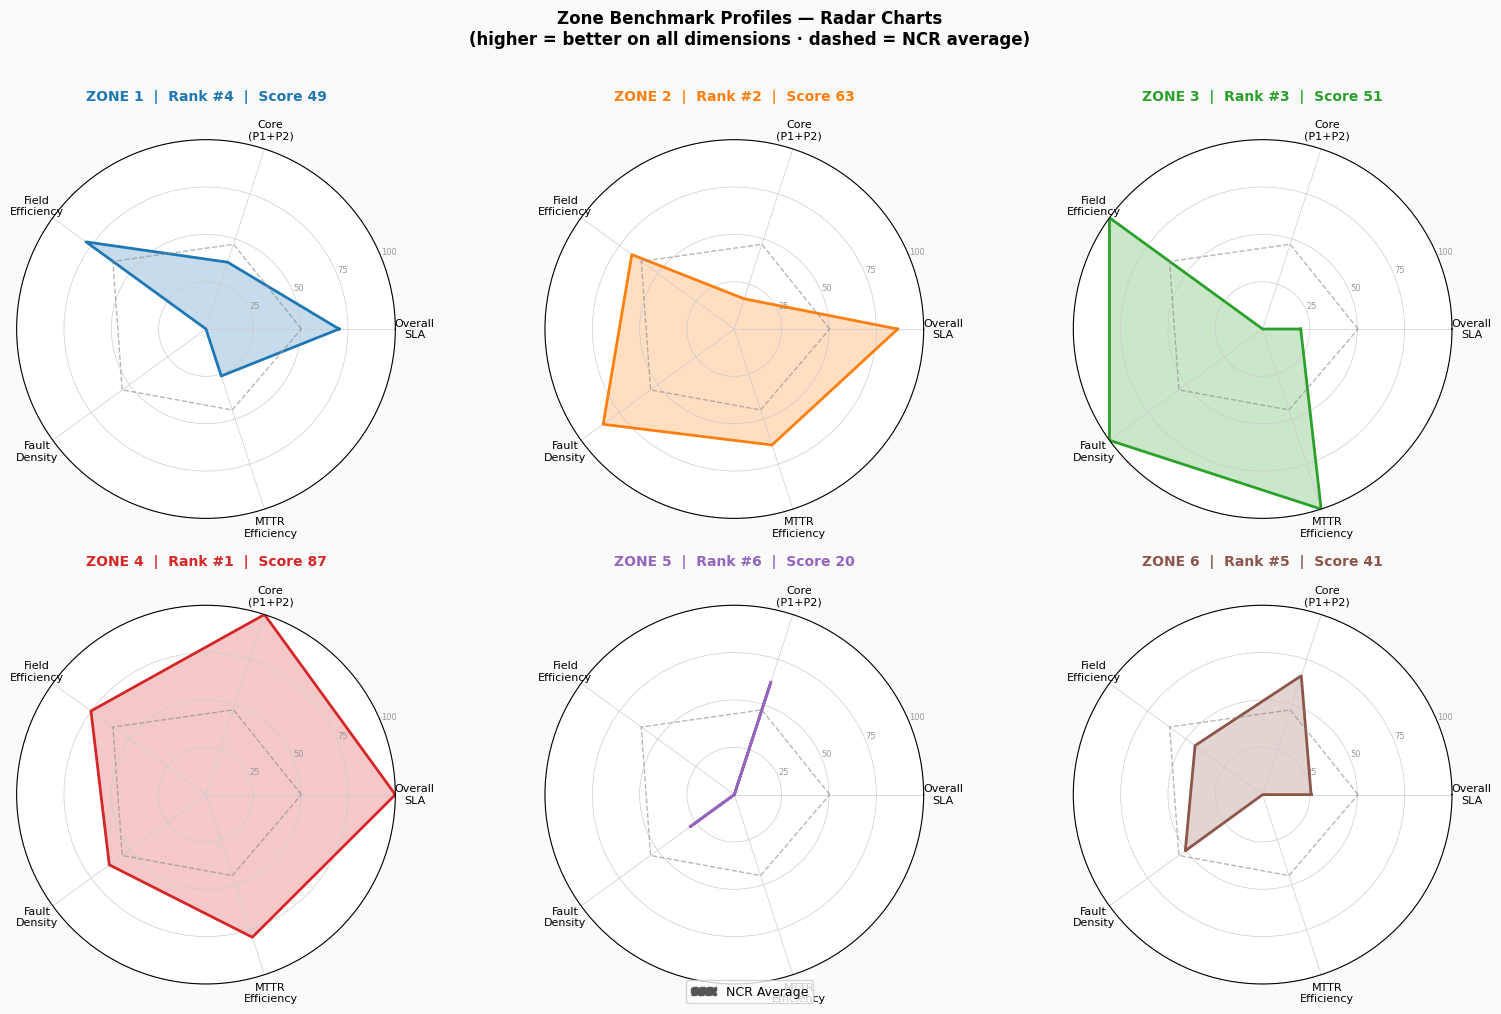

In [4]:
dims = ['SLA_Score','HighPrio_Score','Field_Score','Density_Score','MTTR_Score']
dim_labels = ['Overall\nSLA','Core\n(P1+P2)','Field\nEfficiency',
              'Fault\nDensity','MTTR\nEfficiency']
N = len(dims)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close polygon

fig, axes = plt.subplots(2, 3, figsize=(16, 10),
                          subplot_kw=dict(projection='polar'))
fig.patch.set_facecolor('#fafafa')
axes = axes.flatten()

for i, zone in enumerate(ZONE_ORDER):
    ax = axes[i]
    values = scorecard.loc[zone, dims].tolist()
    values += values[:1]

    color = ZONE_PALETTE[zone]
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)

    # NCR average line
    ncr_vals = scorecard[dims].mean().tolist()
    ncr_vals += ncr_vals[:1]
    ax.plot(angles, ncr_vals, color='#888', linewidth=1,
            linestyle='--', alpha=0.6)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(dim_labels, size=8)
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(['25','50','75','100'], size=6, color='#999')
    ax.grid(color='#ccc', linewidth=0.5)
    composite = scorecard.loc[zone, 'Composite']
    rank      = scorecard.loc[zone, 'Rank']
    ax.set_title(f"{zone}  |  Rank #{rank}  |  Score {composite:.0f}",
                 size=10, fontweight='bold', pad=14, color=color)

# Hide unused subplot (6 zones, 6 subplots — none unused but add legend)
legend_patches = [
    mpatches.Patch(color='#555', linestyle='--', label='NCR Average'),
]
fig.legend(handles=legend_patches, loc='lower center', fontsize=9,
           ncol=1, bbox_to_anchor=(0.5, 0.01), framealpha=0.8)

fig.suptitle('Zone Benchmark Profiles — Radar Charts\n(higher = better on all dimensions · dashed = NCR average)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/figures/project3_ncr/11_scorecard_radar.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 5. Composite Score Bar — Final Zone Ranking

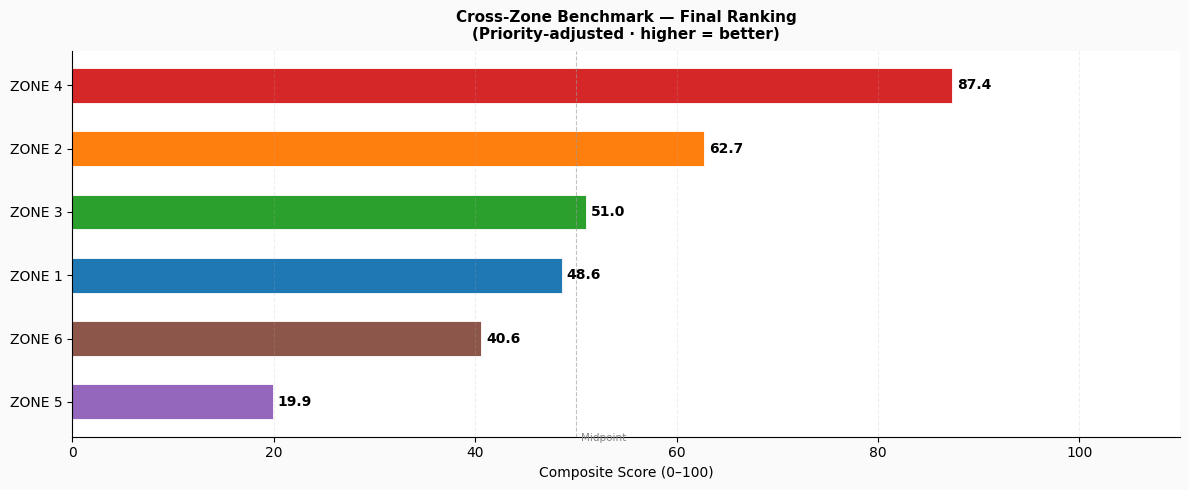


=== FINAL ZONE RANKING ===
  #1  ZONE 4  Composite: 87.4  (SLA 100 · Core P1+P2 100 · Field 75 · Density 63 · MTTR 79)
  #2  ZONE 2  Composite: 62.7  (SLA 86 · Core P1+P2 17 · Field 67 · Density 86 · MTTR 64)
  #3  ZONE 3  Composite: 51.0  (SLA 20 · Core P1+P2 0 · Field 100 · Density 100 · MTTR 100)
  #4  ZONE 1  Composite: 48.6  (SLA 70 · Core P1+P2 37 · Field 78 · Density 0 · MTTR 26)
  #5  ZONE 6  Composite: 40.6  (SLA 26 · Core P1+P2 66 · Field 44 · Density 50 · MTTR 0)
  #6  ZONE 5  Composite: 19.9  (SLA 0 · Core P1+P2 62 · Field 0 · Density 29 · MTTR 0)


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#fafafa')

ranked = scorecard.sort_values('Composite', ascending=True)
colors = [ZONE_PALETTE[z] for z in ranked.index]
bars = ax.barh(ranked.index, ranked['Composite'], color=colors,
               edgecolor='white', linewidth=0.6, height=0.55)

for bar, val in zip(bars, ranked['Composite']):
    ax.text(bar.get_width() + 0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10, fontweight='bold')

# Dimension breakdown mini-stacked
left = np.zeros(len(ranked))
dim_colors = ['#2ecc71','#27ae60','#3498db','#e67e22','#e74c3c']
dim_names  = ['SLA (30%)','Core SLA P1+P2 (25%)','Field (20%)','Density (15%)','MTTR (10%)']
weighted   = {d: ranked[d]*w for d, w in WEIGHTS.items()}

ax.set_xlim(0, 110)
ax.set_xlabel('Composite Score (0–100)', fontsize=10)
ax.set_title('Cross-Zone Benchmark — Final Ranking\n'
             '(Priority-adjusted · higher = better)',
             fontsize=11, fontweight='bold', pad=8)
ax.axvline(50, color='#999', linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(50.5, -0.5, 'Midpoint', fontsize=7.5, color='#888', va='top')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig('reports/figures/project3_ncr/11_composite_ranking.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n=== FINAL ZONE RANKING ===")
for zone in scorecard.sort_values('Composite', ascending=False).index:
    row = scorecard.loc[zone]
    print(f"  #{int(row['Rank'])}  {zone}  Composite: {row['Composite']:.1f}  "
          f"(SLA {row['SLA_Score']:.0f} · Core P1+P2 {row['HighPrio_Score']:.0f} · "
          f"Field {row['Field_Score']:.0f} · Density {row['Density_Score']:.0f} · "
          f"MTTR {row['MTTR_Score']:.0f})")

## 6. Next Steps

→ **Notebook 12** — Project 3 Business Summary and Recommendations.